In [2]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from pathlib import Path

mac = Path("/Users/aressanuylatorre/")

if (mac / "Desktop/doc/NPG").exists():
    BASE = str(mac / "Desktop/doc/NPG")
    NOU  = f"{BASE}/fitxers"
    ANT  = f"{BASE}/antfiles"
else:
    BASE = "/home/aressanuy/Desktop/doc/NPG/entropianou"
    NOU  = f"{BASE}/nou"
    ANT  = f"{BASE}/antic"

# ==================================================
# PARELLES (T_abans, T_despres, P)
# ==================================================

parelles = {
    1:    (300, 305),
    1000: (310, 315),
    2000: (320, 325),
    3000: (325, 330),
    4000: (330, 335),
    5000: (335, 340),
}

def nou_abans(P):
    t_abans, _ = parelles[P]
    return f"{NOU}/ang_ori_{t_abans}_{P}_2.dat"

def nou_despres(P):
    _, t_despres = parelles[P]
    return f"{NOU}/ang_ori_{t_despres}_{P}_2.dat"

def antic_abans(P):
    t_abans, _ = parelles[P]
    return f"{ANT}/ang_fix_{P}_{t_abans}.dat"

def antic_despres(P):
    _, t_despres = parelles[P]
    return f"{ANT}/ang_fix_{P}_{t_despres}.dat"

In [3]:
# =========================
# CONSTANTS I CODIS
# =========================
k      = 1.380649e-23
mmol   = 0.10415        # kg/mol
nmol   = 512
NA     = 6.02214076e23
massa  = mmol/ NA   # kg (massa molecula del sistema)


def entropy_conf(fname, bins=70):
    """Entropia conformacional via histograma 2D (psi, phi)."""
    psi, phi = [], []
    with open(fname) as f:
        for _ in range(3):
            f.readline()
        for line in f:
            if not line.strip() or line.startswith('*'):
                continue
            cols = line.split()
            try:
                psi.append(float(cols[6]))
                phi.append(float(cols[7]))
            except (IndexError, ValueError):
                continue

    edges = np.linspace(-180, 180, bins + 1)
    hist, _, _ = np.histogram2d(psi, phi, bins=[edges, edges], density=True)
    Ap = 360 / bins
    p  = hist * Ap * Ap
    S  = -k * np.sum(p[p > 0] * np.log(p[p > 0])) + k * np.log(Ap * Ap)
    return S / massa, p

def entropy_ori(fname, bins=100):
    th, phi, psi = [], [], []
    with open(fname) as f:
        for _ in range(4): f.readline()
        for line in f:
            cols = line.split()
            try:
                th.append(float(cols[8]))
                phi.append(float(cols[9]))
                psi.append(float(cols[10]))
            except (IndexError, ValueError):
                continue

    intervals = [
        np.linspace(-1, 1, bins + 1),      # bins+1 edges → bins intervals
        np.linspace(-180, 180, bins + 1),
        np.linspace(-180, 180, bins + 1),
    ]

    hist, edges = np.histogramdd((th, phi, psi), bins=intervals)

    # Normalitzar explícitament → p suma 1 sempre
    p = hist / hist.sum()

    # Àrea del bin per la correcció d'entropia
    dth  = edges[0][1]  - edges[0][0]
    dphi = edges[1][1]  - edges[1][0]
    dpsi = edges[2][1]  - edges[2][0]
    A = dth * dphi * dpsi

    S = -k * np.sum(p[p > 0] * np.log(p[p > 0])) + k * np.log(A)
    return S / massa, p

def calcula_entropia(ruta_fitxer, bins):
    intv = bins
    with open(ruta_fitxer, 'r') as fitxer:
        psi, phi = [], []
        for _ in range(4):
            fitxer.readline()

        for _ in range(1001):
            steps = 0
            max_steps = 1001
            while steps < max_steps:
                line = fitxer.readline()
                if not line or '*************' in line:
                    break
                p = line.split()
                if len(p) >= 8:
                    psi.append(float(p[6]))
                    phi.append(float(p[7]))
                steps += 1

    i_psi = np.linspace(-180, 180, intv)
    i_phi = np.linspace(-180, 180, intv)
    hist2d, _, _ = np.histogram2d(psi, phi, bins=[i_psi, i_phi], density=True)

    k = 1.38e-23
    Ap = 360 / intv
    Aa = 360 / intv
    p = hist2d * Ap * Aa 
    pp = Ap * Aa
    sumi = 0
    f, c = p.shape
    for i in range(1, f):
        for j in range(1, c):
            if p[i][j] != 0:
                sumi += p[i][j] * np.log(p[i][j])

    S = -k * sumi + k * np.log(Ap * Aa)
    S = S /massa
    return S,p

def calcula_entropia2(ruta_fitxer, bins):
    intv = bins
    with open(ruta_fitxer, 'r') as fitxer:
        llth, llphi, llpsi = [], [], []
        for _ in range(4):
            fitxer.readline()
        for _ in range(1001):
            steps = 0
            while steps < 1001:
                line = fitxer.readline()
                if not line or '*************' in line:
                    break
                p = line.split()
                if len(p) >= 11:
                    llth.append(float(p[8]))
                    llphi.append(float(p[9]))
                    llpsi.append(float(p[10]))
                steps += 1

    intervals_the = np.linspace(-1,   1,   intv)
    intervals_phi = np.linspace(-180, 180, intv)
    intervals_psi = np.linspace(-180, 180, intv)

    histogram, _ = np.histogramdd((llth, llphi, llpsi),
                                   bins=[intervals_the, intervals_phi, intervals_psi],
                                   density=True)

    Ath = 2   / intv
    Aph = 360 / intv
    Aps = 360 / intv

    
    p = histogram * Ath * Aph * Aps

    sumi = 0
    f, c, a = p.shape
    for i in range(1, f):
        for j in range(1, c):
            for m in range(1, a):
                if p[i][j][m] != 0:
                    sumi += p[i][j][m] * np.log(p[i][j][m])

    S = -k * sumi + k * np.log(Ath * Aph * Aps)
    return S / massa, p

def entropy_ori_nou(fname, bins=20):
    
    def get_edges(a):
        if a == 8:
            return np.linspace(-1, 1, bins + 1)
        else:
            return np.linspace(-180, 180, bins + 1)

    th, phi, psi = [], [], []
    with open(fname) as f:
        for _ in range(3):
            f.readline()
        for line in f:
            if not line.strip() or line.startswith('*'):
                continue
            cols = line.split()
            try:
                th.append(float(cols[8]))
                phi.append(float(cols[9]))
                psi.append(float(cols[10]))
            except (IndexError, ValueError):
                continue

    def S_2d(x, y, a1, a2):
        e1, e2 = get_edges(a1), get_edges(a2)
        hist, _, _ = np.histogram2d(x, y, bins=[e1, e2])
        p = hist / hist.sum()
        A = (e1[1]-e1[0]) * (e2[1]-e2[0])
        return -k * np.sum(p[p > 0] * np.log(p[p > 0])) + k * np.log(A)

    def S_1d(x, a):
        e = get_edges(a)
        hist, _ = np.histogram(x, bins=e)
        p = hist / hist.sum()
        d = e[1] - e[0]
        return -k * np.sum(p[p > 0] * np.log(p[p > 0])) + k * np.log(d)

    Sthphi  = S_2d(th, phi, 8, 9)
    Sthpsi  = S_2d(th, psi, 8, 10)
    Sphipsi = S_2d(phi, psi, 9, 10)
    Sth     = S_1d(th,  8)
    Sphi    = S_1d(phi, 9)
    Spsi    = S_1d(psi, 10)

    Stot = Sthphi + Sthpsi + Sphipsi - Sth - Sphi - Spsi
    return Stot / massa , p


In [ ]:
def compare_entropy_by_bins(bins_list,
                             file_216_a, file_216_b,
                             file_512_a, file_512_b,
                             entropy_fn=entropy_ori,
                             ylabel=r'$\Delta S$ (J / kg K)'):
    S216, S512 = [], []
    for b in bins_list:
        S216a = entropy_fn(file_216_a, bins=b)[0]
        S216b = entropy_fn(file_216_b, bins=b)[0]
        S216.append(S216a - S216b)
        S512a = entropy_fn(file_512_a, bins=b)[0]
        S512b = entropy_fn(file_512_b, bins=b)[0]
        S512.append(S512a - S512b)

    S216, S512 = np.array(S216), np.array(S512)

    for b, s216, s512 in zip(bins_list, S216, S512):
        print(f"bins={b:3d}  S216={s216:.6e}  S512={s512:.6e} ")
        print(f"{S216b} ")
        print(f"{S216a} ")

    plt.figure(figsize=(8, 5))
    plt.plot(bins_list, S216, '-o', label='216')
    plt.plot(bins_list, S512, '-o', label='512')
    plt.xlabel('bins')
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True, ls='--', lw=0.4)
    plt.tight_layout()
    plt.show()

    return S216, S512

def compare_entropy_by_bins2(bins_list,
                             file_216_a, file_216_b,
                             file_512_a, file_512_b,
                             entropy_fn=calcula_entropia,
                             ylabel=r'$\Delta S$ (J / kg K)'):
    S216, S512 = [], []
    for b in bins_list:
        S216a = entropy_fn(file_216_a, intv=b)[0]
        S216b = entropy_fn(file_216_b, intv=b)[0]
        S216.append(S216a - S216b)
        S512a = entropy_fn(file_512_a, intv=b)[0]
        S512b = entropy_fn(file_512_b, intv=b)[0]
        S512.append(S512a - S512b)

    S216, S512 = np.array(S216), np.array(S512)


    plt.figure(figsize=(8, 5))
    plt.plot(bins_list, S216, '-o', label='216')
    plt.plot(bins_list, S512, '-o', label='512')
    plt.xlabel('bins')
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True, ls='--', lw=0.4)
    plt.tight_layout()
    plt.show()

    return S216, S512

bins_list = np.arange(250, 251, 10)
#bins_list = np.arange(250, 251, 100)
P = 3000
file_216_b = nou_abans(P)
file_216_a = nou_despres(P)
file_512_b = nou_abans(P)
file_512_a = nou_despres(P)
#file_512_b = "/home/aressanuy/Desktop/doc/NPG/entropianou/ang_fix_NPG_300.dat"
#file_512_a = "/home/aressanuy/Desktop/doc/NPG/entropianou/ang_fix_NPG_305.dat"


# Amb entropy_conf 
compare_entropy_by_bins(bins_list, file_216_a, file_216_b, file_512_a, file_512_b, entropy_fn=entropy_ori2, ylabel=r'$\Delta S_{conf}$ (J / kg K)')
#compare_entropy_by_bins2(bins_list, file_216_a, file_216_b, file_512_a, file_512_b, entropy_fn=calcula_entropia2, ylabel=r'$\Delta S_{conf}$ (J / kg K)')

P=    1 bar  K Sc1=624.1638517270851 Sc2=774.6161885239673 Sc=150.45233679688215 So1=648.4561174682555 So2=983.2719585675501 So=334.81584109929463  St=485.2681778961768  J/(kg·K)
P= 1000 bar  K Sc1=629.5629034251198 Sc2=778.9047839467155 Sc=149.34188052159573 So1=659.5527753306874 So2=981.5276748093767 So=321.9748994786893  St=471.316780000285  J/(kg·K)
P= 2000 bar  K Sc1=639.0075760501403 Sc2=783.8176542781027 Sc=144.81007822796244 So1=682.6445276983114 So2=979.7770983278469 So=297.1325706295355  St=441.94264885749794  J/(kg·K)
P= 3000 bar  K Sc1=656.2348250432906 Sc2=785.2395226052055 Sc=129.0046975619149 So1=707.9952200230164 So2=978.222849383131 So=270.22762936011463  St=399.23232692202953  J/(kg·K)
P= 4000 bar  K Sc1=653.8607608836923 Sc2=787.6177567151929 Sc=133.7569958315006 So1=705.3998122326351 So2=976.3956030387097 So=270.99579080607464  St=404.75278663757524  J/(kg·K)
P= 5000 bar  K Sc1=715.754795902266 Sc2=787.2904255491839 Sc=71.53562964691787 So1=807.5834091816636 So2=963

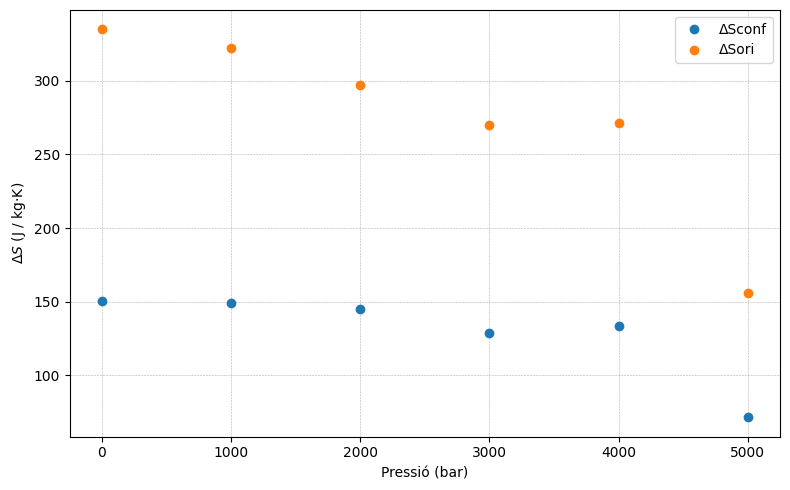

In [ ]:
resultats = []

for  P in parelles:

    Sc = -entropy_conf(nou_abans(P), bins=200)[0] + entropy_conf(nou_despres(P), bins=200)[0]
    Sc1 = entropy_conf(nou_abans(P), bins=200)[0]
    Sc2 = entropy_conf(nou_despres(P), bins=200)[0]
    So = -entropy_ori(nou_abans(P), bins=20)[0] + entropy_ori(nou_despres(P), bins=20)[0]
    So1 = entropy_ori(nou_abans(P), bins=20)[0]
    So2 = entropy_ori(nou_despres(P), bins=20)[0]
    St = Sc + So

    resultats.append((P, Sc, So, St))
    print(f"P={P:5d} bar  K Sc1={Sc1} Sc2={Sc2} Sc={Sc} So1={So1} So2={So2} So={So}  St={St}  J/(kg·K)")

# Plot
pressions = [r[0] for r in resultats]
Sc_list   = [r[1] for r in resultats]
So_list   = [r[2] for r in resultats]
St_list   = [r[3] for r in resultats]

plt.figure(figsize=(8,5))
plt.plot(pressions, Sc_list, 'o', label='ΔSconf')
plt.plot(pressions, So_list, 'o', label='ΔSori')
#plt.plot(pressions, St_list, 'o', label='ΔStotal')
plt.xlabel('Pressió (bar)')
plt.ylabel(r'$\Delta S$ (J / kg·K)')
plt.legend()
plt.grid(True, ls='--', lw=0.4)
plt.tight_layout()
plt.show()

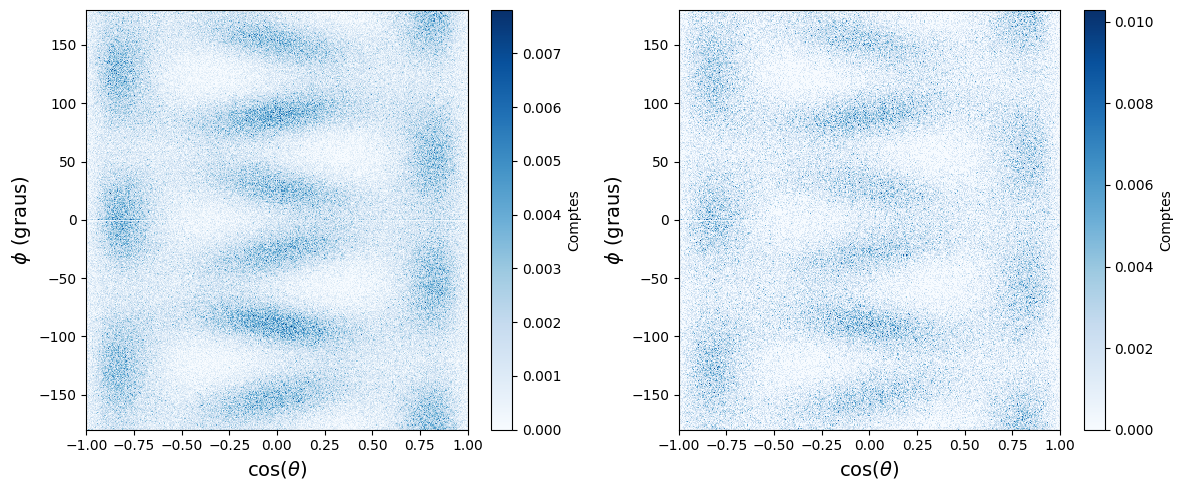

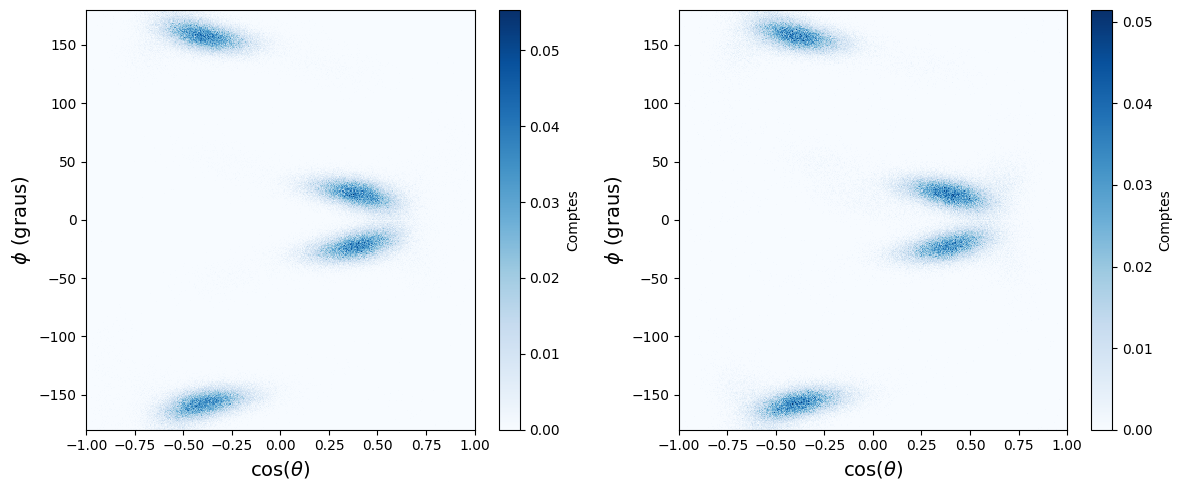

In [315]:
def read_theta_phior(filename):
    theta, phior = [], []
    with open(filename, "r") as f:
        lines = f.readlines()[4:-1]
    for line in lines:
        v = line.split()
        if len(v) >= 10:
            theta.append(float(v[8]))
            phior.append(float(v[10]))
    return np.array(theta), np.array(phior)

def compare_files_2d(file_list,
                     bins=400,
                     theta_range=(-1, 1),
                     phior_range=(-180, 180)):
    #labels = ['216', '512']
    cmaps  = ['Blues', 'Blues']

    fig, axes = plt.subplots(1, len(file_list), figsize=(6 * len(file_list), 5))
    if len(file_list) == 1:
        axes = [axes]

    for i, filename in enumerate(file_list):
        theta, phior = read_theta_phior(filename)

        hist, xedges, yedges = np.histogram2d(theta, phior, bins=bins,
                                               range=[theta_range, phior_range],density=True)
        mesh = axes[i].pcolormesh(xedges, yedges, hist.T,
                                   cmap=cmaps[i % len(cmaps)])
        #axes[i].set_title(labels[i], fontsize=14)
        axes[i].set_xlabel(r'$\cos(\theta)$', fontsize=14)
        axes[i].set_ylabel(r'$\phi$ (graus)', fontsize=14)
        fig.colorbar(mesh, ax=axes[i], label='Comptes')

    plt.tight_layout()
    #plt.savefig(f"{BASE}/figures/comparativa_2d.png", dpi=150)
    plt.show()


#compare_files_2d([nou_abans(1000),
#antic_abans(1000)
#])



compare_files_2d([nou_despres(1000),
"/home/aressanuy/Desktop/doc/NPG/entropianou/antic/ang_ori_0_305.dat"
])
compare_files_2d([nou_abans(1000),
"/home/aressanuy/Desktop/doc/NPG/entropianou/antic/ang_ori_0_300.dat"
])

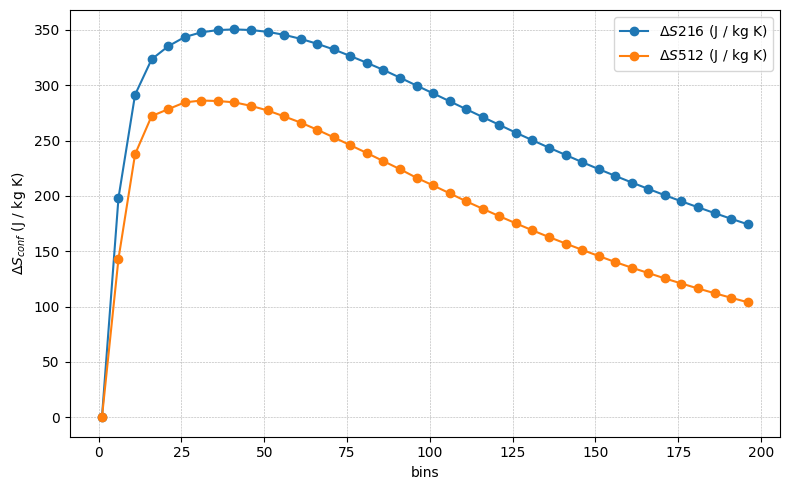

(np.float64(704.2927301642794), np.float64(600.3021432527332))

In [24]:


def compare_entropy_by_bins(bins_list,
                             file_216_a, file_216_b,
                             file_512_a, file_512_b,
                             entropy_fn=entropy_ori,
                             ylabel=r'$\Delta S$ (J / kg K)'):
    S216, S512 = [], []
    llS512a,llS512b = [], []
    for b in bins_list:
        S216a = entropy_fn(file_216_a, bins=b)[0]
        S216b = entropy_fn(file_216_b, bins=b)[0]   
        S216.append(S216a - S216b)
        S512a = entropy_fn(file_512_a, bins=b)[0]
        llS512a.append(S512a)
        S512b = entropy_fn(file_512_b, bins=b)[0]
        llS512b.append(S512b)
        S512.append(S512a - S512b)

    S216, S512 = np.array(S216), np.array(S512)

    #for b, s216, s512 in zip(bins_list, S216, S512):
    #    print(f"bins={b:3d}  S216={s216:.6e}  S512={s512:.6e} ")
    #    print(f"{S216b} ")
    #    print(f"{S216a} ")

    plt.figure(figsize=(8, 5))
    #plt.plot(bins_list, llS512a, '-o', label='300')
    plt.plot(bins_list, S216, '-o', label=r'$\Delta S 216$ (J / kg K)')
    plt.plot(bins_list, S512, '-o', label=r'$\Delta S 512$ (J / kg K)')
    plt.xlabel('bins')
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True, ls='--', lw=0.4)
    plt.tight_layout()
    plt.show()

    return S512a, S512b

def compare_entropy_by_bins2(bins_list,
                             file_216_a, file_216_b,
                             file_512_a, file_512_b,
                             entropy_fn=calcula_entropia,
                             ylabel=r'$\Delta S$ (J / kg K)'):
    S216, S512 = [], []
    for b in bins_list:
        S216a = entropy_fn(file_216_a, intv=b)
        S216b = entropy_fn(file_216_b, intv=b)
        S216.append(S216a - S216b)
        S512a = entropy_fn(file_512_a, intv=b)
        S512b = entropy_fn(file_512_b, intv=b)
        S512.append(S512a - S512b)

    S216, S512 = np.array(S216), np.array(S512)


    plt.figure(figsize=(8, 5))
    plt.plot(bins_list, S216, '-o', label='216')
    plt.plot(bins_list, S512, '-o', label='512')
    plt.xlabel('bins')
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True, ls='--', lw=0.4)
    plt.tight_layout()
    plt.show()

    return S216, S512

bins_list = np.arange(1, 200, 5)
#bins_list = np.arange(350, 351, 100)

P = 1
file_216_b = nou_abans(P)
file_216_a = nou_despres(P)
file_512_b = antic_abans(P)
file_512_a = antic_despres(P)
#file_512_b = "/home/aressanuy/Desktop/doc/NPG/entropianou/ang_fix_NPG_300.dat"
#file_512_a = "/home/aressanuy/Desktop/doc/NPG/entropianou/ang_fix_NPG_305.dat"


# Amb entropy_conf 
compare_entropy_by_bins(bins_list, file_216_a, file_216_b, file_512_a, file_512_b, entropy_fn=entropy_ori, ylabel=r'$\Delta S_{conf}$ (J / kg K)')
#compare_entropy_by_bins2(bins_list, file_216_a, file_216_b, file_512_a, file_512_b, entropy_fn=calcula_entropia, ylabel=r'$\Delta S_{conf}$ (J / kg K)')

In [ ]:
def entropy_ori_with_error(fname, bins=70):
    """Entropia orientacional + error estadístic."""
    th, phi, psi = [], [], []
    with open(fname) as f:
        for _ in range(4):
            f.readline()
        for line in f:
            cols = line.split()
            try:
                th.append(float(cols[8]))
                phi.append(float(cols[9]))
                psi.append(float(cols[10]))
            except (IndexError, ValueError):
                continue

    intervals = [
        np.linspace(-1,   1,   bins),
        np.linspace(-180, 180, bins),
        np.linspace(-180, 180, bins),
    ]

    # Usem density=False per tenir counts bruts → necessari per l'error
    counts, _ = np.histogramdd((th, phi, psi), bins=intervals, density=False)
    N = counts.sum()

    Ath = 2 / bins
    A   = Ath * (360 / bins) * (360 / bins)
    p   = counts / N  # probabilitat per bin (sense density)

    mask = p > 0

    # Entropia (equivalent a l'original)
    S = -k * np.sum(p[mask] * np.log(p[mask] / A))  # corregim pel volum del bin

    # Error estadístic de Shannon
    log_p = np.log(p[mask] / A)
    E1 = np.sum(p[mask] * log_p**2)
    E2 = (np.sum(p[mask] * log_p))**2
    sigma_S = k * np.sqrt((E1 - E2) / N)

    S_scaled   = S / massa * nmol
    err_scaled = sigma_S / massa * nmol

    return S_scaled, err_scaledimport numpy as np



def compare_entropy_ori_by_bins(bins_list,
                                file_216_a, file_216_b,
                                file_512_a, file_512_b):
    So216, So512 = [], []
    Err216, Err512 = [], []

    for b in bins_list:
        S216_a, e216_a = entropy_ori_with_error(file_216_a, bins=b)
        S216_b, e216_b = entropy_ori_with_error(file_216_b, bins=b)
        So216.append(S216_a - S216_b)
        Err216.append(np.sqrt(e216_a**2 + e216_b**2))

        S512_a, e512_a = entropy_ori_with_error(file_512_a, bins=b)
        S512_b, e512_b = entropy_ori_with_error(file_512_b, bins=b)
        So512.append(S512_a - S512_b)
        Err512.append(np.sqrt(e512_a**2 + e512_b**2))

    return (np.array(So216), np.array(Err216),
            np.array(So512), np.array(Err512))


# ── execució ──────────────────────────────────────────────────────────────────
bins_list = np.arange(20, 421, 20)
file_216_a = antic_abans(305, 1)
file_216_b = antic_abans(300, 1)
file_512_a = nou_abans(305, 1)
file_512_b = nou_abans(300, 1)

So216, Err216, So512, Err512 = compare_entropy_ori_by_bins(
    bins_list,
    file_216_a, file_216_b,
    file_512_a, file_512_b
)


# ── plot ──────────────────────────────────────────────────────────────────────
plt.figure(figsize=(8, 5))
plt.errorbar(bins_list, So216, yerr=Err216, fmt='-o', label='216', capsize=3)
plt.errorbar(bins_list, So512, yerr=Err512, fmt='-o', label='512', capsize=3)
plt.xlabel('bins')
plt.ylabel(r'$\Delta S_{ori}$ (J / kg K)')
plt.legend()
plt.grid(True, ls='--', lw=0.4)
plt.tight_layout()


In [8]:

def count_points(fname):
    th = []
    with open(fname) as f:
        for _ in range(4): f.readline()
        for line in f:
            cols = line.split()
            try:
                th.append(float(cols[8]))
            except (IndexError, ValueError):
                continue
    print(f"N punts: {len(th)}")
    return len(th)

count_points(nou_abans(1))
def diagnose_histogram(p, N, label=""):
    total = p.size
    buits = np.sum(p < 1/N)
    print(f"{label}")
    print(f"  Total bins:     {total}")
    print(f"  Bins buits:     {buits}  ({100*buits/total:.1f}%)")
    print(f"  Bins ocupats:   {total - buits}  ({100*(1-buits/total):.1f}%)")
    print(f"  p_max:          {p.max():.4f}")
    print(f"  sum(p):         {p.sum():.4f}")


N punts: 512000


N punts: 512000


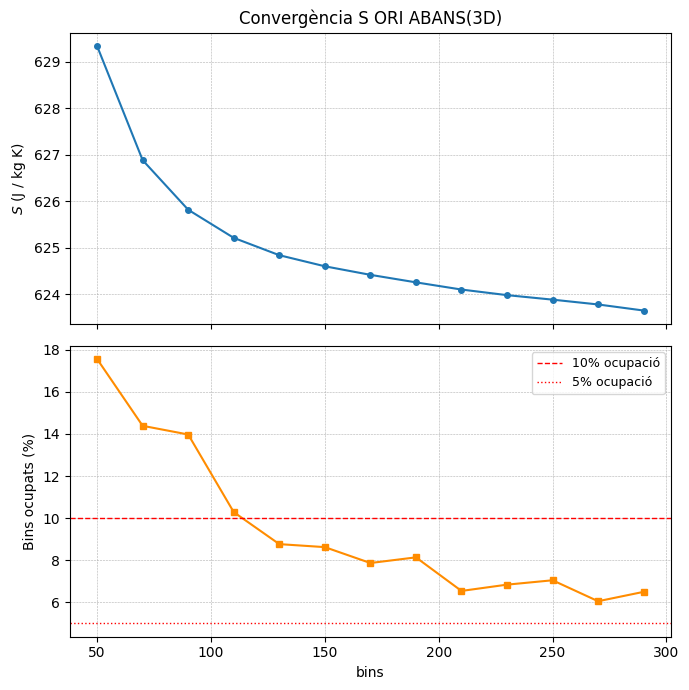

N punts: 512000


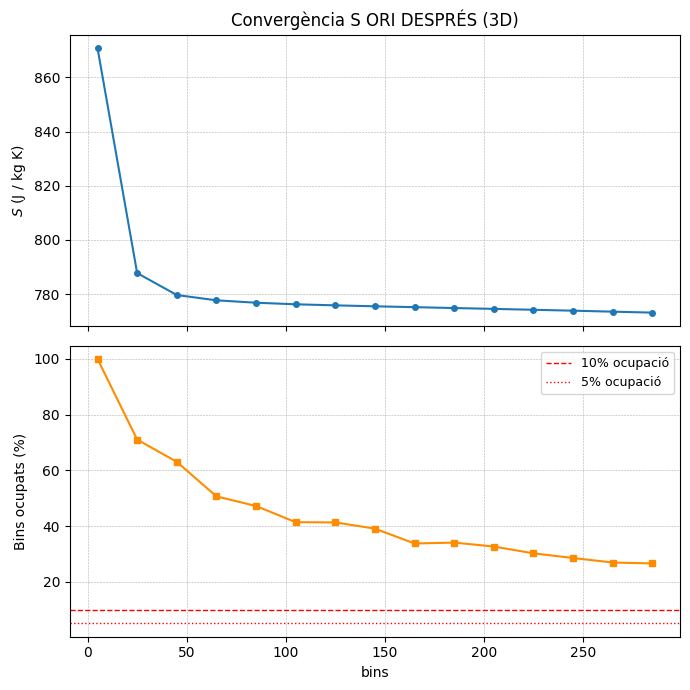

In [10]:
def convergence_plot(fname, entropy_fn, bins_list, label=""):
    S_list = []
    occ_list = []
    N = count_points(fname)
    
    for b in bins_list:
        S, p = entropy_fn(fname, bins=b)
        S_list.append(S)
        occ_list.append(100 * np.sum(p >= 1/N) / p.size)
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 7), sharex=True)
    
    ax1.plot(bins_list, S_list, '-o', ms=4)
    ax1.set_ylabel(r'$S$ (J / kg K)')
    ax1.set_title(label)
    ax1.grid(True, ls='--', lw=0.4)
    
    ax2.plot(bins_list, occ_list, '-s', ms=4, color='darkorange')
    ax2.axhline(10, color='red', lw=1, ls='--', label='10% ocupació')
    ax2.axhline(5,  color='red', lw=1, ls=':',  label='5% ocupació')
    ax2.set_ylabel('Bins ocupats (%)')
    ax2.set_xlabel('bins')
    ax2.legend(fontsize=9)
    ax2.grid(True, ls='--', lw=0.4)
    
    plt.tight_layout()
    plt.show()
    
    return np.array(S_list), np.array(occ_list)


# Per conf (2D) — rang gran
S_conf, occ_conf = convergence_plot(
    nou_abans(1), entropy_conf,
    bins_list=np.arange(50, 300, 20),
    label="Convergència S ORI ABANS(3D)"
)

# Per ori (3D) — rang petit!
S_ori, occ_ori = convergence_plot(
    nou_despres(1), entropy_conf,
    bins_list=np.arange(5, 300, 20),
    label="Convergència S ORI DESPRÉS (3D)"
)



N punts: 512000


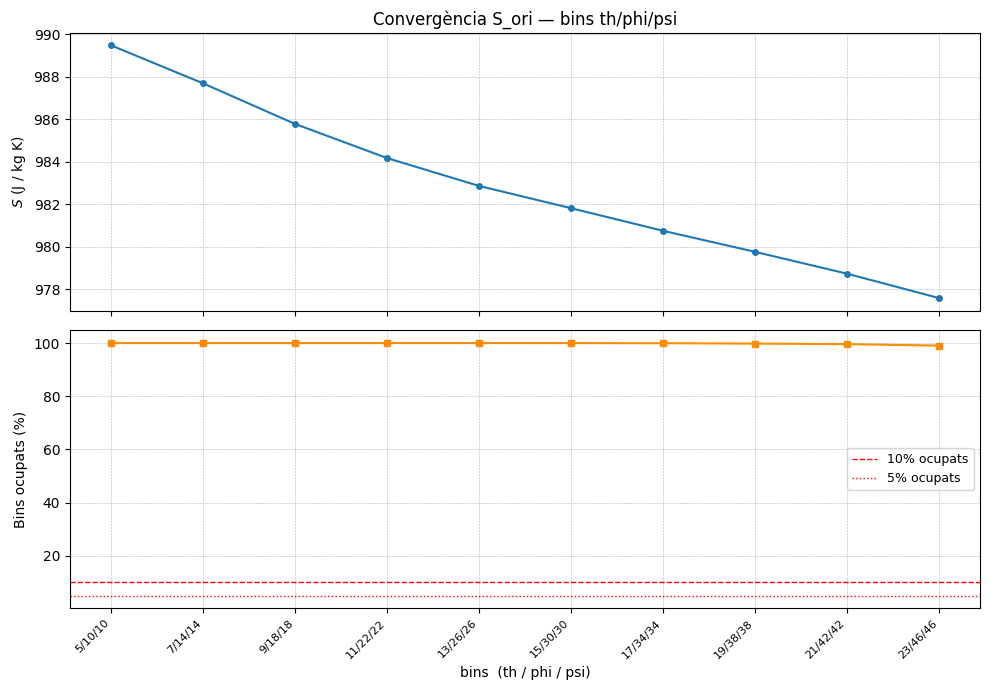

In [350]:
def convergence_plot_ori3(fname, bins_th_list, bins_phi_list, bins_psi_list, label=""):
    """
    bins_th_list, bins_phi_list, bins_psi_list : llistes de la mateixa longitud
    """
    assert len(bins_th_list) == len(bins_phi_list) == len(bins_psi_list), \
        "Les tres llistes han de tenir la mateixa longitud"

    S_list   = []
    occ_list = []
    N = count_points(fname)

    for bth, bphi, bpsi in zip(bins_th_list, bins_phi_list, bins_psi_list):
        S, p = entropy_ori2(fname, bins_th=bth, bins_phi=bphi, bins_psi=bpsi)
        S_list.append(S)
        occ_list.append(100 * np.sum(p >= 1/N) / p.size)

    x = range(len(bins_th_list))
    xlabels = [f"{bth}/{bphi}/{bpsi}" for bth, bphi, bpsi in 
               zip(bins_th_list, bins_phi_list, bins_psi_list)]

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

    ax1.plot(x, S_list, '-o', ms=4)
    ax1.set_ylabel(r'$S$ (J / kg K)')
    ax1.set_title(label)
    ax1.grid(True, ls='--', lw=0.4)

    ax2.plot(x, occ_list, '-s', ms=4, color='darkorange')
    ax2.axhline(10, color='red', lw=1, ls='--', label='10% ocupats')
    ax2.axhline(5,  color='red', lw=1, ls=':',  label='5% ocupats')
    ax2.set_ylabel('Bins ocupats (%)')
    ax2.set_xlabel('bins  (th / phi / psi)')
    ax2.set_xticks(list(x))
    ax2.set_xticklabels(xlabels, rotation=45, ha='right', fontsize=8)
    ax2.legend(fontsize=9)
    ax2.grid(True, ls='--', lw=0.4)

    plt.tight_layout()
    plt.show()

    return np.array(S_list), np.array(occ_list)

bins_th  = np.arange(5, 25, 2)           # rang petit [-1, 1]
bins_phi = np.arange(10, 50, 4)          # rang gran [-180, 180]o (2
bins_psi = np.arange(10, 50, 4)          # rang gran [-180, 180]

S_ori, occ_ori = convergence_plot_ori3(
    nou_despres(1),
    bins_th_list=bins_th,
    bins_phi_list=bins_phi,
    bins_psi_list=bins_psi,
    label="Convergència S_ori — bins th/phi/psi"
)

# Entropy ORI with SUM

N punts: 512000


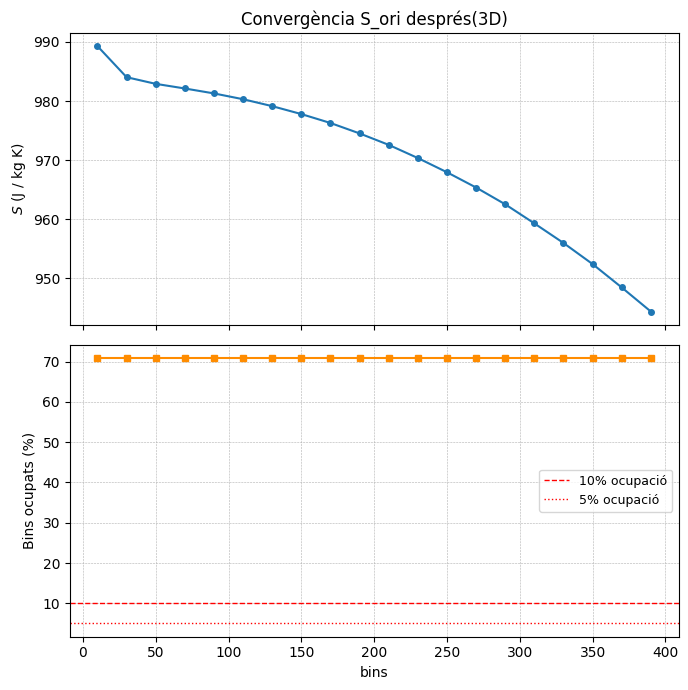

N punts: 512000


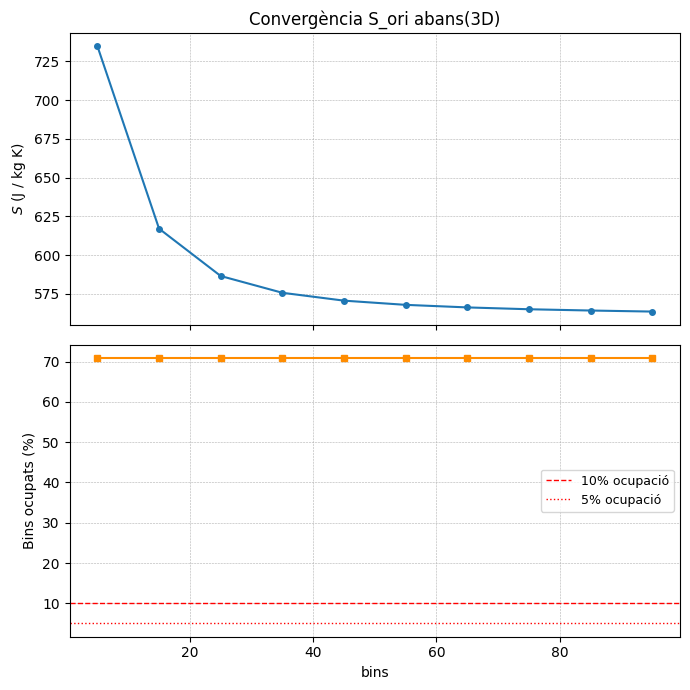

452.3711132633076


In [307]:
# Per conf (2D) — rang gran
S_conf, occ_conf = convergence_plot(
    nou_despres(1), entropy_ori_nou,
    bins_list=np.arange(10, 400, 20),
    label="Convergència S_ori després(3D)"
)

# Per ori (3D) — rang petit!
S_ori, occ_ori = convergence_plot(
    nou_abans(1), entropy_ori_nou,
    bins_list=np.arange(5, 100, 10),
    label="Convergència S_ori abans(3D)"
)

S1 = entropy_ori_nou(nou_abans(1), bins=1000)[0]
S2 = entropy_ori_nou(nou_despres(1), bins=200)[0]
print(S2-S1)

bins= 10  Stot=6.273663e+02  Sth-phi=3.717563e+02  Sth-psi=3.759855e+02  Sphi-psi=7.185004e+02  Sth=1.560179e+01  Sphi=4.083558e+02  Spsi=4.149184e+02
bins= 30  Stot=5.800682e+02  Sth-phi=3.485306e+02  Sth-psi=3.511149e+02  Sphi-psi=6.871237e+02  Sth=1.014983e+01  Sphi=3.937178e+02  Spsi=4.028334e+02
bins= 50  Stot=5.690375e+02  Sth-phi=3.427244e+02  Sth-psi=3.463289e+02  Sphi-psi=6.780997e+02  Sth=9.663880e+00  Sphi=3.887632e+02  Spsi=3.996884e+02
bins= 70  Stot=5.656220e+02  Sth-phi=3.409792e+02  Sth-psi=3.449021e+02  Sphi-psi=6.754945e+02  Sth=9.537487e+00  Sphi=3.873738e+02  Spsi=3.988425e+02
bins= 90  Stot=5.638016e+02  Sth-phi=3.400613e+02  Sth-psi=3.441673e+02  Sphi-psi=6.742274e+02  Sth=9.466941e+00  Sphi=3.867255e+02  Spsi=3.984619e+02
bins=110  Stot=5.627253e+02  Sth-phi=3.395744e+02  Sth-psi=3.437090e+02  Sphi-psi=6.736023e+02  Sth=9.448937e+00  Sphi=3.864375e+02  Spsi=3.982739e+02
bins=130  Stot=5.618242e+02  Sth-phi=3.391475e+02  Sth-psi=3.433805e+02  Sphi-psi=6.731480e+02

/tmp/ipykernel_3135560/1007562976.py:73: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(bins_list, results[k], '-o', label=k,


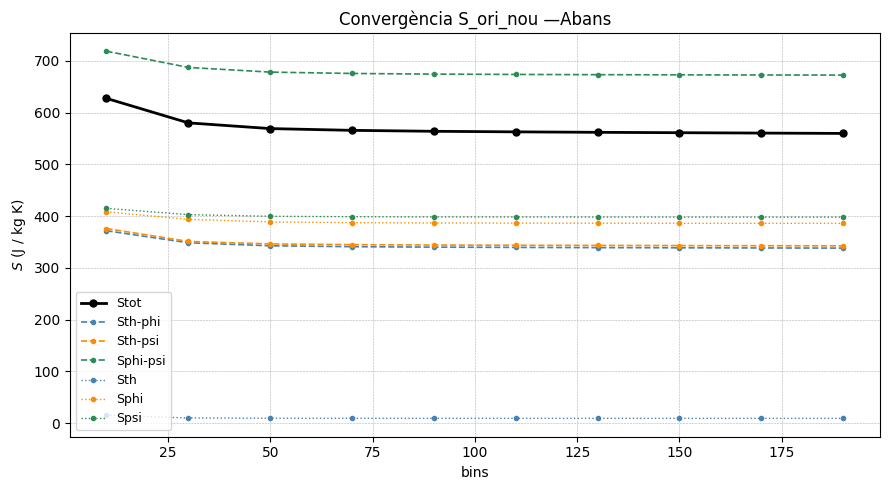

bins= 10  Stot=9.893021e+02  Sth-phi=5.228520e+02  Sth-psi=5.209269e+02  Sphi-psi=9.379104e+02  Sth=5.379174e+01  Sphi=4.693801e+02  Spsi=4.692153e+02
bins= 30  Stot=9.840401e+02  Sth-phi=5.202137e+02  Sth-psi=5.179325e+02  Sphi-psi=9.359109e+02  Sth=5.239932e+01  Sphi=4.687596e+02  Spsi=4.688581e+02
bins= 50  Stot=9.829118e+02  Sth-phi=5.197735e+02  Sth-psi=5.174054e+02  Sphi-psi=9.354219e+02  Sth=5.225796e+01  Sphi=4.686574e+02  Spsi=4.687736e+02
bins= 70  Stot=9.821275e+02  Sth-phi=5.194846e+02  Sth-psi=5.171130e+02  Sphi-psi=9.351068e+02  Sth=5.221394e+01  Sphi=4.686168e+02  Spsi=4.687460e+02
bins= 90  Stot=9.812917e+02  Sth-phi=5.192043e+02  Sth-psi=5.168134e+02  Sphi-psi=9.348046e+02  Sth=5.219811e+01  Sphi=4.686040e+02  Spsi=4.687286e+02
bins=110  Stot=9.803093e+02  Sth-phi=5.188758e+02  Sth-psi=5.164777e+02  Sphi-psi=9.344641e+02  Sth=5.219181e+01  Sphi=4.685937e+02  Spsi=4.687227e+02
bins=130  Stot=9.791359e+02  Sth-phi=5.184859e+02  Sth-psi=5.160557e+02  Sphi-psi=9.340866e+02

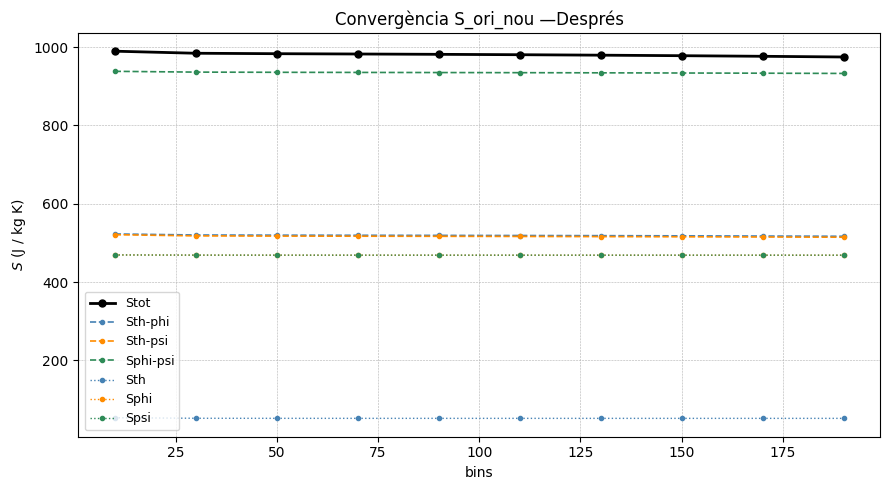

In [462]:
def entropy_ori_nou_plot(fname, bins=20):
    
    def get_edges(a):
        if a == 8:
            return np.linspace(-1, 1, bins + 1)
        else:
            return np.linspace(-180, 180, bins + 1)

    th, phi, psi = [], [], []
    with open(fname) as f:
        for _ in range(3):
            f.readline()
        for line in f:
            if not line.strip() or line.startswith('*'):
                continue
            cols = line.split()
            try:
                th.append(float(cols[8]))
                phi.append(float(cols[9]))
                psi.append(float(cols[10]))
            except (IndexError, ValueError):
                continue

    def S_2d(x, y, a1, a2):
        e1, e2 = get_edges(a1), get_edges(a2)
        hist, _, _ = np.histogram2d(x, y, bins=[e1, e2])
        p = hist / hist.sum()
        A = (e1[1]-e1[0]) * (e2[1]-e2[0])
        return -k * np.sum(p[p > 0] * np.log(p[p > 0])) + k * np.log(A)

    def S_1d(x, a):
        e = get_edges(a)
        hist, _ = np.histogram(x, bins=e)
        p = hist / hist.sum()
        d = e[1] - e[0]
        return -k * np.sum(p[p > 0] * np.log(p[p > 0])) + k * np.log(d)

    Sthphi  = S_2d(th, phi, 8, 9)  / massa
    Sthpsi  = S_2d(th, psi, 8, 10) / massa
    Sphipsi = S_2d(phi, psi, 9, 10)/ massa
    Sth     = S_1d(th,  8)         / massa
    Sphi    = S_1d(phi, 9)         / massa
    Spsi    = S_1d(psi, 10)        / massa

    Stot = Sthphi + Sthpsi + Sphipsi - Sth - Sphi - Spsi
    print(f"bins={bins:3d}  Stot={Stot:.6e}  Sth-phi={Sthphi:.6e}  Sth-psi={Sthpsi:.6e}  Sphi-psi={Sphipsi:.6e}  Sth={Sth:.6e}  Sphi={Sphi:.6e}  Spsi={Spsi:.6e}")
    return Stot, Sthphi, Sthpsi, Sphipsi, Sth, Sphi, Spsi


def convergence_plot_ori_nou(fname, bins_list, label=""):

    keys   = ['Stot', 'Sth-phi', 'Sth-psi', 'Sphi-psi', 'Sth', 'Sphi', 'Spsi']
    styles = [
        dict(color='black',      lw=2,   ls='-',  ms=5),   # Stot
        dict(color='steelblue',  lw=1.2, ls='--', ms=3),   # Sth-phi
        dict(color='darkorange', lw=1.2, ls='--', ms=3),   # Sth-psi
        dict(color='seagreen',   lw=1.2, ls='--', ms=3),   # Sphi-psi
        dict(color='steelblue',  lw=1,   ls=':',  ms=3),   # Sth
        dict(color='darkorange', lw=1,   ls=':',  ms=3),   # Sphi
        dict(color='seagreen',   lw=1,   ls=':',  ms=3),   # Spsi
    ]

    results = {k: [] for k in keys}

    for b in bins_list:
        vals = entropy_ori_nou_plot(fname, bins=b)
        for k, v in zip(keys, vals):
            results[k].append(v)

    fig, ax = plt.subplots(figsize=(9, 5))

    for k, st in zip(keys, styles):
        ax.plot(bins_list, results[k], '-o', label=k,
                color=st['color'], lw=st['lw'], ls=st['ls'], ms=st['ms'])

    ax.set_xlabel('bins')
    ax.set_ylabel(r'$S$ (J / kg K)')
    ax.set_title(label)
    ax.legend(fontsize=9)
    ax.grid(True, ls='--', lw=0.4)
    plt.tight_layout()
    plt.show()

    return {k: np.array(v) for k, v in results.items()}
llp = [1]
for P in llp:
    results = convergence_plot_ori_nou(
        nou_abans(P),
        bins_list=np.arange(10, 200, 20),
        label="Convergència S_ori_nou —Abans"
    )
    results = convergence_plot_ori_nou(
        nou_despres(P),
        bins_list=np.arange(10, 200, 20),
        label="Convergència S_ori_nou —Després"
)

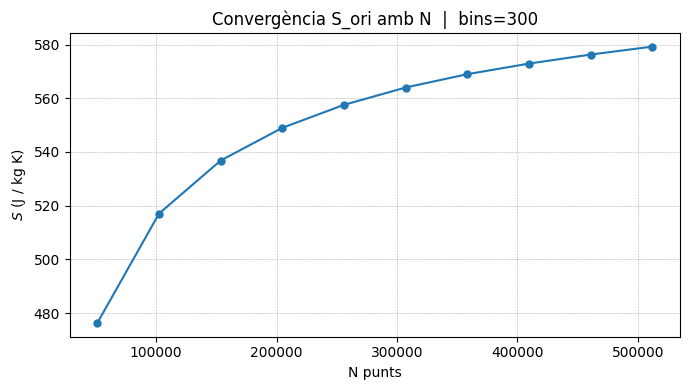

In [327]:
def convergence_plot_N(fname, bins, fractions, label=""):
    """
    Calcula S amb fraccions creixents del dataset per veure si converge amb N.
    fractions : ex [0.2, 0.4, 0.6, 0.8, 1.0]
    """
    # Llegir totes les dades
    th, phi, psi = [], [], []
    with open(fname) as f:
        for _ in range(4): f.readline()
        for line in f:
            cols = line.split()
            try:
                th.append(float(cols[8]))
                phi.append(float(cols[9]))
                psi.append(float(cols[10]))
            except (IndexError, ValueError):
                continue

    th, phi, psi = np.array(th), np.array(phi), np.array(psi)
    N_total = len(th)

    intervals = [
        np.linspace(-1,   1,   bins + 1),
        np.linspace(-180, 180, bins + 1),
        np.linspace(-180, 180, bins + 1),
    ]

    S_list, N_list = [], []
    for frac in fractions:
        N = int(N_total * frac)
        hist, edges = np.histogramdd((th[:N], phi[:N], psi[:N]), bins=intervals)
        p = hist / hist.sum()
        dth  = edges[0][1] - edges[0][0]
        dphi = edges[1][1] - edges[1][0]
        dpsi = edges[2][1] - edges[2][0]
        A = dth * dphi * dpsi
        S = -k * np.sum(p[p > 0] * np.log(p[p > 0])) + k * np.log(A)
        S_list.append(S / massa)
        N_list.append(N)

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(N_list, S_list, '-o', ms=5)
    ax.set_xlabel('N punts')
    ax.set_ylabel(r'$S$ (J / kg K)')
    ax.set_title(f"{label}  |  bins={bins}")
    ax.grid(True, ls='--', lw=0.4)
    plt.tight_layout()
    plt.show()

    return np.array(N_list), np.array(S_list)

N_list, S_list = convergence_plot_N(
    nou_abans(1),
    bins=300,
    fractions=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    label="Convergència S_ori amb N"
)


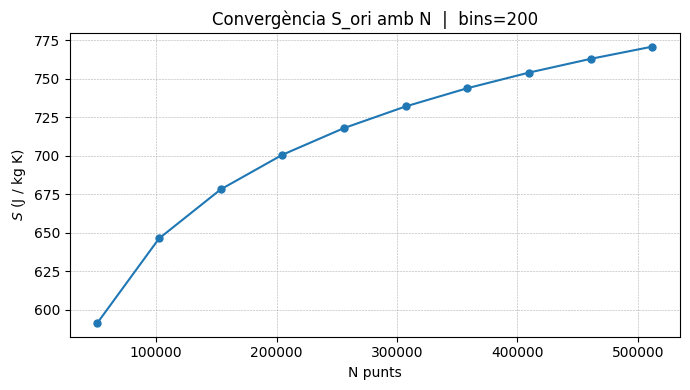

S extrapolada N→∞: 842.61 J/kg K


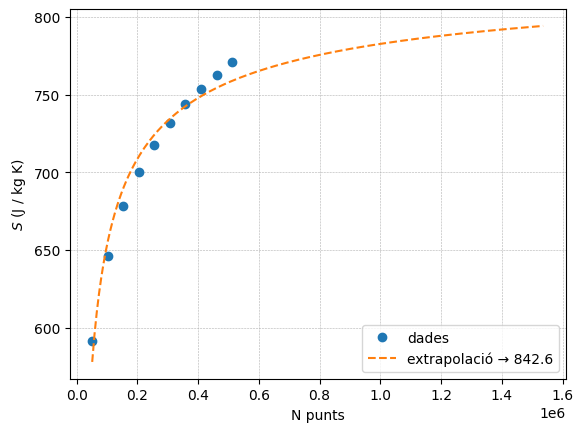

In [341]:
from scipy.optimize import curve_fit

N_list, S_list = convergence_plot_N(
    nou_despres(1),
    bins=200,
    fractions=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    label="Convergència S_ori amb N"
)

def model(N, S_inf, a):
    return S_inf - a / np.sqrt(N)   # comportament típic del biaix

popt, _ = curve_fit(model, N_list, S_list)
S_infinit = popt[0]
print(f"S extrapolada N→∞: {S_infinit:.2f} J/kg K")

# Plot
N_extrap = np.linspace(N_list[0], N_list[-1]*3, 200)
plt.plot(N_list, S_list, 'o', label='dades')
plt.plot(N_extrap, model(N_extrap, *popt), '--', label=f'extrapolació → {S_infinit:.1f}')
plt.xlabel('N punts')
plt.ylabel(r'$S$ (J / kg K)')
plt.legend()
plt.grid(True, ls='--', lw=0.4)
plt.show()

In [12]:
def count_points(fname):
    th = []
    with open(fname) as f:
        for _ in range(4): f.readline()
        for line in f:
            cols = line.split()
            try:
                th.append(float(cols[8]))
            except (IndexError, ValueError):
                continue
    return len(th)


def diagnose_histogram_counts(fname, bins, entropy_fn=entropy_ori, label=""):
    S, p = entropy_fn(fname, bins=bins)
    
    # Reconstruir counts (p normalitzada → multipliquem per N)
    N = count_points(fname)
    counts = p * N  # counts aproximats per bin
    
    ocupats = counts[counts > 0]
    
    mean_counts  = ocupats.mean()
    median_counts = np.median(ocupats)
    below_thresh  = np.sum(ocupats < 7)
    pct_below     = 100 * below_thresh / len(ocupats)
    return mean_counts, median_counts


def convergence_plot_counts(fname, bins_list, entropy_fn=entropy_ori, 
                             threshold=7, label=""):
    N = count_points(fname)
    S_list, mean_list, median_list, pct_below_list = [], [], [], []

    for b in bins_list:
        S, p = entropy_fn(fname, bins=b)
        counts = p * N

        ocupats = counts[counts > 0]
        mean_c   = ocupats.mean()
        median_c = np.median(ocupats)
        pct_below = 100 * np.sum(ocupats < threshold) / len(ocupats)

        S_list.append(S)
        mean_list.append(mean_c)
        median_list.append(median_c)
        pct_below_list.append(pct_below)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 7), sharex=True)

    ax1.plot(bins_list, S_list, '-o', ms=4)
    ax1.set_ylabel(r'$S$ (J / kg K)')
    ax1.set_title(label)
    ax1.grid(True, ls='--', lw=0.4)

    ax2.plot(bins_list, mean_list,   '-o', ms=4, color='steelblue',  label='mitjana counts/bin')
    ax2.plot(bins_list, median_list, '-s', ms=4, color='darkorange', label='mediana counts/bin')
    ax2.axhline(threshold, color='red', lw=1.2, ls='--', 
                label=f'llindar {threshold} counts')
    ax2.set_ylabel('Counts per bin ocupat')
    ax2.set_xlabel('bins')
    ax2.legend(fontsize=9)
    ax2.grid(True, ls='--', lw=0.4)

    plt.tight_layout()
    plt.show()

    return (np.array(S_list), np.array(mean_list), 
            np.array(median_list), np.array(pct_below_list))

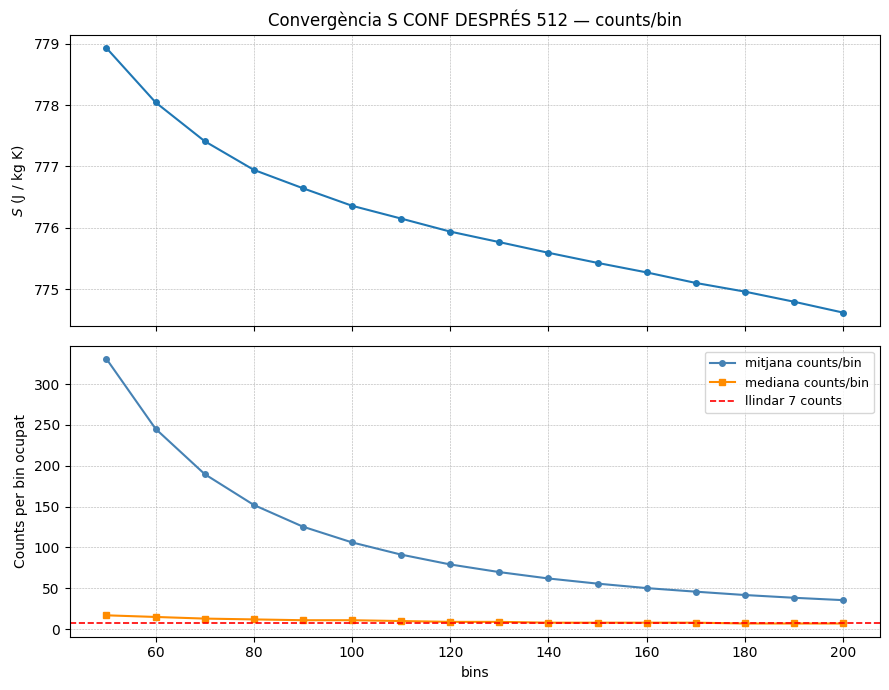

[330.74935401 245.21072797 189.77020015 152.06415206 125.49019608
 106.22406639  91.28186843  79.23243578  69.88806989  62.0756547
  55.77342048  50.29963651  45.9316408   41.83690145  38.47020813
  35.57037655] [17. 15. 13. 12. 11. 11. 10.  9.  9.  8.  8.  8.  8.  7.  7.  7.]


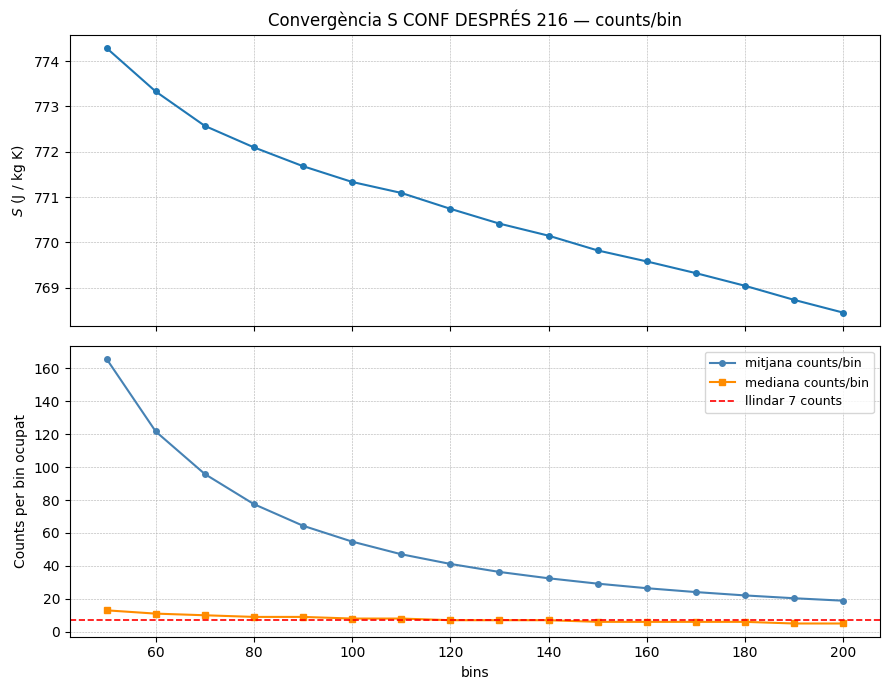

626.5085691560581 777.1885765207478 150.6800073646897
627.3069569296099 772.3706757397969 145.06371881018697


In [16]:
P = 1

S_list, mean_c, median_c, pct_below = convergence_plot_counts(
    nou_despres(P), entropy_fn=entropy_conf,
    bins_list=np.arange(50, 201, 10),
    threshold=7,
    label="Convergència S CONF DESPRÉS 512 — counts/bin"
)
print(mean_c, median_c)
S_list, mean_c, median_c, pct_below = convergence_plot_counts(
    antic_despres(P), entropy_fn=entropy_conf,
    bins_list=np.arange(50, 201, 10),
    threshold=7,
    label="Convergència S CONF DESPRÉS 216 — counts/bin"
)
S512a = entropy_conf(nou_abans(P), 75)[0]
S512b = entropy_conf(nou_despres(P), 75)[0]
print(S512a, S512b, S512b - S512a)
S512a = entropy_conf(antic_abans(P), 75)[0]
S512b = entropy_conf(antic_despres(P), 75)[0]
print(S512a, S512b, S512b - S512a)

# Prova amb theta, phi

In [468]:
#Stot, Sthphi, Sthpsi, Sphipsi, Sth, Sphi, Spsi
llp = [   1, 1000, 2000, 3000, 4000]
for P in llp:
    print(f"P={P} bar")
    n = 1
    bins = 100
    S512a = entropy_ori_nou_plot(nou_abans(P), 50)[n]
    S512b = entropy_ori_nou_plot(nou_despres(P), 50)[n]
    print(S512a, S512b, S512b - S512a)
    S512a = entropy_ori_nou_plot(antic_abans(P), 50)[n]
    S512b = entropy_ori_nou_plot(antic_despres(P), 50)[n]
    print(S512a, S512b, S512b - S512a)

P=1 bar
bins= 50  Stot=5.690375e+02  Sth-phi=3.427244e+02  Sth-psi=3.463289e+02  Sphi-psi=6.780997e+02  Sth=9.663880e+00  Sphi=3.887632e+02  Spsi=3.996884e+02
bins= 50  Stot=9.829118e+02  Sth-phi=5.197735e+02  Sth-psi=5.174054e+02  Sphi-psi=9.354219e+02  Sth=5.225796e+01  Sphi=4.686574e+02  Spsi=4.687736e+02
342.72436237467406 519.7735333166181 177.04917094194406
bins= 50  Stot=6.039131e+02  Sth-phi=3.546010e+02  Sth-psi=3.473036e+02  Sphi-psi=7.009507e+02  Sth=1.359265e+01  Sphi=3.975295e+02  Spsi=3.878201e+02
bins= 50  Stot=9.524528e+02  Sth-phi=5.178185e+02  Sth-psi=4.930349e+02  Sphi-psi=9.101158e+02  Sth=5.264428e+01  Sphi=4.676625e+02  Spsi=4.482095e+02
354.60099945964186 517.8184570842707 163.21745762462882
P=1000 bar
bins= 50  Stot=5.853163e+02  Sth-phi=3.534578e+02  Sth-psi=3.528769e+02  Sphi-psi=6.897194e+02  Sth=1.269526e+01  Sphi=3.956266e+02  Spsi=4.024160e+02
bins= 50  Stot=9.812111e+02  Sth-phi=5.191082e+02  Sth-psi=5.163424e+02  Sphi-psi=9.347368e+02  Sth=5.191791e+01  

FileNotFoundError: [Errno 2] No such file or directory: '/home/aressanuy/Desktop/doc/NPG/entropianou/antic/ang_fix_4000_330.dat'

N punts: 512000


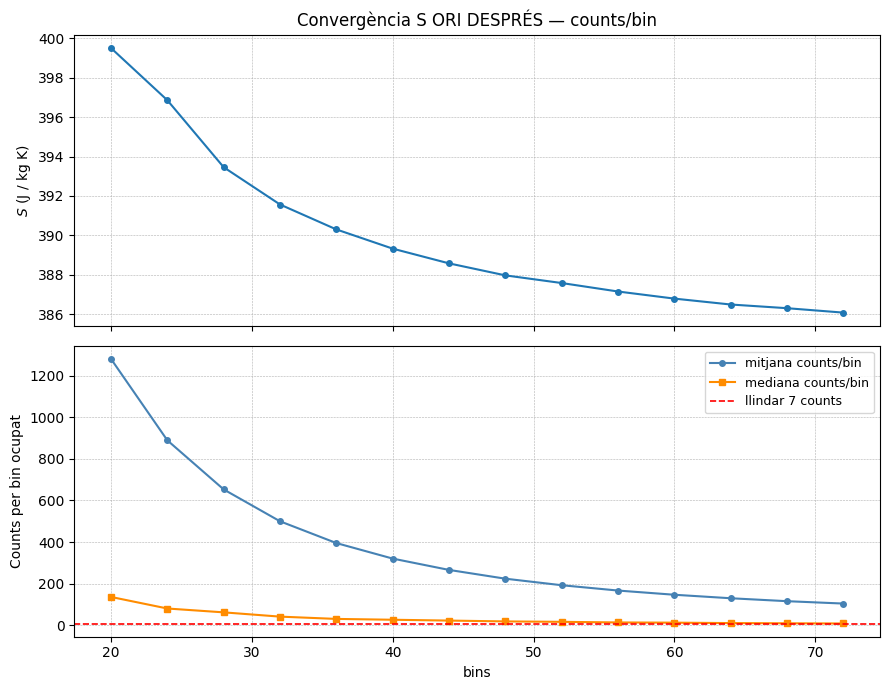

N punts: 216000


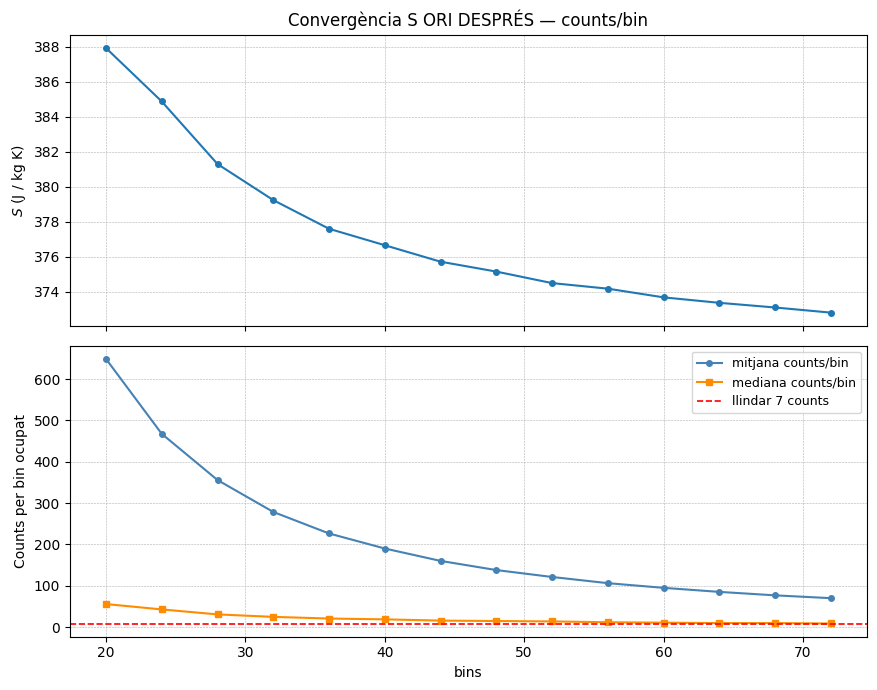

In [473]:
def entropy_thephi(fname, bins=70):
    """Entropia conformacional via histograma 2D (psi, phi)."""
    psi, phi = [], []
    with open(fname) as f:
        for _ in range(3):
            f.readline()
        for line in f:
            if not line.strip() or line.startswith('*'):
                continue
            cols = line.split()
            try:
                psi.append(float(cols[8]))
                phi.append(float(cols[9]))
            except (IndexError, ValueError):
                continue

    edges = np.linspace(-180, 180, bins + 1)
    edges1 = np.linspace(-1, 1, bins + 1)
    hist, _, _ = np.histogram2d(psi, phi, bins=[edges1, edges], density=True)
    Ap = 360 / bins
    Ap1 = 2 / bins
    p  = hist * Ap * Ap1
    S  = -k * np.sum(p[p > 0] * np.log(p[p > 0])) + k * np.log(Ap * Ap1)
    return S / massa, p
P =3000
S_list, mean_c, median_c, pct_below = convergence_plot_counts(
    nou_abans(P), entropy_fn=entropy_thephi,
    bins_list=np.arange(20, 76, 4),
    threshold=7,
    label="Convergència S ORI DESPRÉS — counts/bin"
)

S_list, mean_c, median_c, pct_below = convergence_plot_counts(
    antic_abans(P), entropy_fn=entropy_thephi,
    bins_list=np.arange(20, 76, 4),
    threshold=7,
    label="Convergència S ORI DESPRÉS — counts/bin"
)